# <center> LINMA2474 - Project 1 : Graph learning and image inpainting with Riemannian optimization</center>

#### <center>27-02-2026 V1</center>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

import torch
import pymanopt
from pymanopt.manifolds import Sphere, FixedRankEmbedded
from pymanopt.optimizers import SteepestDescent, TrustRegions

## Write your additional imports here

In [2]:
np.random.seed(42)
torch.random.manual_seed(42);

## 1. CIFAR-10 dataset

In [3]:
## Do not modify ##
channels = 3
p = 32
n = p*p

N_part1 = 200
N_part2 = 32
N_green_frog = N_part1+N_part2

N_class  = 5000
N_batch  = 10000
N_test   = 10000
N_sample = 50000
## ############# ##

#### 1.1 Load data

In [4]:
## Load Dataset ##
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

def extract_data_and_swap_axes(dataset):
    data = dataset[b'data'].reshape((N_batch, 3, p, p))
    labels = dataset[b'labels']
    data = np.swapaxes(data, 1, 3)
    data = np.swapaxes(data, 1, 2)
    return data, labels

list_batches = []
list_labels = []
for i in range(5):
    dataset = unpickle(f"cifar-10-batches-py/data_batch_{i+1}")
    dataset, labels = extract_data_and_swap_axes(dataset)
    list_batches.append(dataset)
    list_labels.append(labels)

#### 1.2 Normalize and sample green frogs

In [5]:
## ############# ##
## Do not modify ##
## ############# ##

batches = np.array(list_batches).reshape(N_sample, n*channels) / 255
labels = np.array(list_labels).reshape(N_sample,)
frog_images = torch.from_numpy(batches[labels == 6])

# Select Green Frogs
green_frogs = []

for img in frog_images:
    r_mean = img[0].mean().item()
    g_mean = img[1].mean().item()
    b_mean = img[2].mean().item()

    if g_mean > 1.5 * r_mean and g_mean > 1.5 * b_mean:
        green_frogs.append(img)

green_frogs = torch.stack(green_frogs)

print("Total green frogs:", green_frogs.shape[0])

green_frogs = green_frogs.reshape(N_green_frog, n*channels).T.reshape(n, channels, N_green_frog).numpy()
data_part1 = green_frogs[..., :N_part1]
data_part2 = green_frogs[..., N_part1:]

## ############# ##
## ############# ##
## ############# ##

print(data_part1.shape)
print(data_part2.shape)

Total green frogs: 232
(1024, 3, 200)
(1024, 3, 32)


#### 1.3 Corrupt green frogs of dataset 2

In [6]:
def corrupt_image(img):
    # Generate random mask (20% missing pixels)
    missing_ratio = 0.2
    mask = np.random.rand(n) > missing_ratio 
    mask = np.repeat(mask[:, None], channels, axis=1)

    # Apply forward inpainting operator
    corrupted_img = img * mask
    return corrupted_img, mask

In [7]:
corrupted_data = np.zeros((n, channels, N_part2))
mask_lst = np.zeros((n, channels, N_part2))
for i in range(N_part2):
    y, mask = corrupt_image(data_part2[:,:,i])
    corrupted_data[:,:,i] = y 
    mask_lst[:,:,i] = mask

#### 1.4 Show samples

In [8]:
def show_samples_image(X, p=32, grid_dim=6, title="", width=1.2, height=1.2, SNR_labels=None, channels=channels, N_samples=N_part1, savefig=None, vmin=0, vmax=1):
    """
    Show samples of a dataset X of p x p images.
    @args:
        <numpy array> X: dataset.
        <int> p: dimension of an image.
        <int> grid_dim: dimension of the grid of displayed samples.
        <string> title: title of the grid.
    """
    Y = X.reshape(p, p, channels, N_samples).clip(0,1) 
    fig, axes = plt.subplots(grid_dim,grid_dim)
    fig.suptitle(title)
    fig.set_figheight(grid_dim*width)
    fig.set_figwidth(grid_dim*height)
    #Y = Y - Y.min()
    #Y = Y / Y.max()
    for i in range(grid_dim):
        for j in range(grid_dim):
            axes[i,j].imshow(Y[:,:,:,grid_dim*i+j], vmin=vmin, vmax=vmax)
            axes[i,j].axis("off")
            if SNR_labels is not None:
                axes[i,j].set_title("%.2f" % SNR_labels[grid_dim*i+j])
    
    if savefig is not None:
        plt.savefig(savefig+".pdf", bbox_inches="tight")
    plt.show()

def show_image(x, p=32):
    """
    Show a p x p image.
    @args:
        <numpy array> x: image.
        <int> p: dimension of the image.
    """
    y = (x).reshape(p, p, 3) 
    y = y - y.min()
    y = y / y.max()
    plt.figure(figsize=(1,1))
    plt.imshow(y)
    plt.axis("off")
    plt.show()

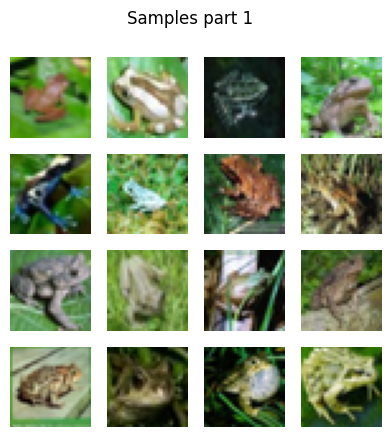

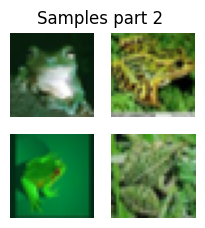

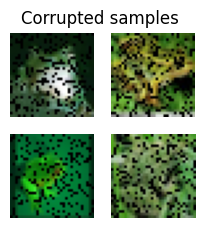

In [9]:
show_samples_image(data_part1, title="Samples part 1", N_samples=N_part1, grid_dim=4)
show_samples_image(data_part2, title="Samples part 2", N_samples=N_part2, grid_dim=2)
show_samples_image(corrupted_data, title="Corrupted samples", N_samples=N_part2, grid_dim=2) 

## 2. Project

In [10]:
## To complete